In [2]:
import numpy as np
import os


input_file = "data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Training/Train_Dst_NoAuction_MinMax_CF_1.txt"
output_dir = "processed_data"
os.makedirs(output_dir, exist_ok=True)


# Load the data matrix
raw_data = np.loadtxt(input_file)
print(f"Original shape: {raw_data.shape}") # 149 by X columns

# Extract Features (First 144 rows) and Transpose to get (Time_Steps, Features)
features = raw_data[:144, :].T

# Extract Labels (Last 5 rows represent different prediction horizons)
labels = raw_data[146, :].T - 1 

print(f"Processed Features shape: {features.shape}") # (X, 144)
print(f"Processed Labels shape: {labels.shape}")     # (X,)
 
np.save(os.path.join(output_dir, "train_features_1.npy"), features)
np.save(os.path.join(output_dir, "train_labels_1.npy"), labels)
print("Success")

Original shape: (149, 39512)
Processed Features shape: (39512, 144)
Processed Labels shape: (39512,)
Success


[0.60146038 0.60146038 0.60123974 ... 0.99226059 0.99203866 0.99203866]


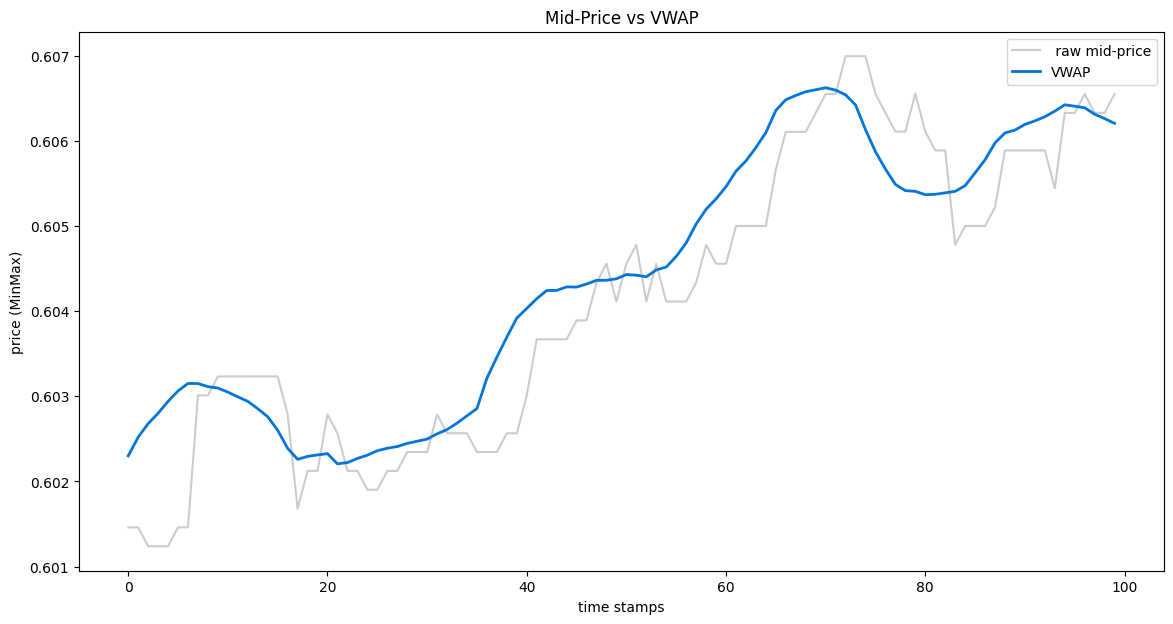

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
data = np.loadtxt(input_file)


ask_price = data[0, :]
ask_volume = data[1, :]  
bid_price = data[2, :]
bid_volume = data[3, :] 

mid_price = (ask_price + bid_price) / 2
# total liquidity
total_volume = ask_volume + bid_volume

# widnow size (n = 10)
window_size = 10
# Price * Volume for VWAP
pv = mid_price * total_volume
# Rolling sum for the VWAP numerator and denominator
def rolling_sum(a, n=10):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n-1:]

vwap_numerator = rolling_sum(pv, window_size)
vwap_denominator = rolling_sum(total_volume, window_size)

# Final VWAP signal
vwap = vwap_numerator / vwap_denominator

time_steps = 100
plt.figure(figsize=(14, 7))
print(mid_price)

plt.plot(mid_price[:time_steps], label=' raw mid-price', color='gray', alpha=0.4)
# !Note: VWAP array is shorter size: (window_size - 1) 
plt.plot(vwap[:time_steps], label='VWAP', color='#0275D8', linewidth=2)

plt.title("Mid-Price vs VWAP")
plt.xlabel("time stamps")
plt.ylabel("price (MinMax)")
plt.legend()
plt.show()